In [54]:
# Imports
import path_simulator
import payoffs
from estimators import finite_difference
from estimators import pathwise
from estimators import likelihood_ratio

import numpy as np
import pandas as pd
import time

from scipy.stats import norm
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import LogLocator, FormatStrFormatter


## Finite Differences



We begin by approximating the delta of a European call option using the method of Finite Differences (Forward and Central) and comparing it against its true delta. We work under the assumptions of the Black-Scholes-Merton model and use the Monte Carlo pricing engine developed.

In [55]:
# Parameters of the European call option
s = 100
K = 100
T = 1
r = 0.05
vol = 0.25
reps = 10000

In [56]:
# Theoretical delta
d1 = (np.log(s/K) + (r + (vol**2)/2) * T) / (vol * (T)**(1/2))
real_delta = norm.cdf(d1)

In [57]:
# Approximate delta (Forward Difference, h = 1)
delta_fd = finite_difference.mc_call_delta_fd_estimate(s,K,T,r,vol,reps,1)

# Approximate delta (Central Difference, h = 1)
delta_cd = finite_difference.mc_call_delta_cd_estimate(s,K,T,r,vol,reps,1)

# Compute errors of estimations
delta_fd_error = abs(delta_fd - real_delta)
delta_cd_error = abs(delta_cd - real_delta)

# Print results
print(f"True delta: {real_delta}")
print(f"Estimated delta (Forward difference): {delta_fd} | Error: {delta_fd_error}")
print(f"Estimated delta (Central difference): {delta_cd} | Error: {delta_cd_error}")

True delta: 0.627409464153284
Estimated delta (Forward difference): 0.9201603322029825 | Error: 0.2927508680496985
Estimated delta (Central difference): 0.8057910948139453 | Error: 0.17838163066066126


Both approximations appear to be accurate. In order to understand the effect of increasing/decreasing the number of simulations $N$ and the step size $h$ on both methods, we compute the average mean-squared error (MSE) under varying parameter values. 

In [58]:
# Values to investigate
reps_values = np.logspace(3, 6, 7, dtype=int)
h_values = np.logspace(-2, 2, 9)

We begin with obtaining tables of values for both.

In [59]:
trials = 5

# Rows correspond to reps, columns correspond to h
fd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_call_delta_fd_estimate(s,K,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_fd - real_delta)**2
        fd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_error_table = pd.DataFrame(fd_mse, index=reps_values, columns=h_values)

fd_error_table.index.name = "reps"
fd_error_table.columns.name = "h"

display(fd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,4408.849823,846.925049,101.708898,9.628328,2.003871,0.124850,0.005528,0.040884,0.086136
3162,1965.972957,92.828476,63.230620,2.355098,0.090972,0.020194,0.002551,0.025930,0.092923
10000,292.014741,40.677489,6.251339,1.119319,0.050881,0.006512,0.001423,0.031274,0.089041
31622,50.509745,56.468226,1.514590,0.133120,0.005036,0.004562,0.005762,0.030316,0.088377
100000,123.240585,8.964685,0.751602,0.047689,0.009111,0.003972,0.004642,0.031362,0.089086
316227,27.421003,4.824459,0.414315,0.019423,0.001399,0.000822,0.004913,0.031533,0.089028
1000000,11.589196,0.102416,0.087427,0.003179,0.000830,0.000453,0.005145,0.031430,0.089053


In [60]:
trials = 5

# Rows correspond to reps, columns correspond to h
cd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_call_delta_cd_estimate(s,K,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_cd - real_delta)**2
        cd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_error_table = pd.DataFrame(cd_mse, index=reps_values, columns=h_values)

cd_error_table.index.name = "reps"
cd_error_table.columns.name = "h"

display(cd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,4005.198666,135.314163,9.814376,2.161287,0.086063,0.006314,0.000352,0.001798,0.010051
3162,377.088504,86.657171,6.387589,0.353685,0.039731,0.006282,0.000199,0.002678,0.010690
10000,301.490590,38.831662,0.759411,0.210498,0.022077,0.004624,0.000298,0.001975,0.011012
31622,12.616551,1.847853,0.224346,0.071306,0.012086,0.000913,0.000059,0.001960,0.010865
100000,24.271533,1.109300,0.131066,0.011376,0.000328,0.000257,0.000029,0.001988,0.010647
316227,4.589726,0.266446,0.017645,0.006887,0.000088,0.000047,0.000051,0.001886,0.010681
1000000,0.818979,0.124123,0.010663,0.001558,0.000398,0.000010,0.000022,0.001917,0.010578


We plot the results obtained.

In [61]:
shared_vmin = min(fd_mse[fd_mse > 0].min(),cd_mse[cd_mse > 0].min())

shared_vmax = max(fd_mse.max(),cd_mse.max())

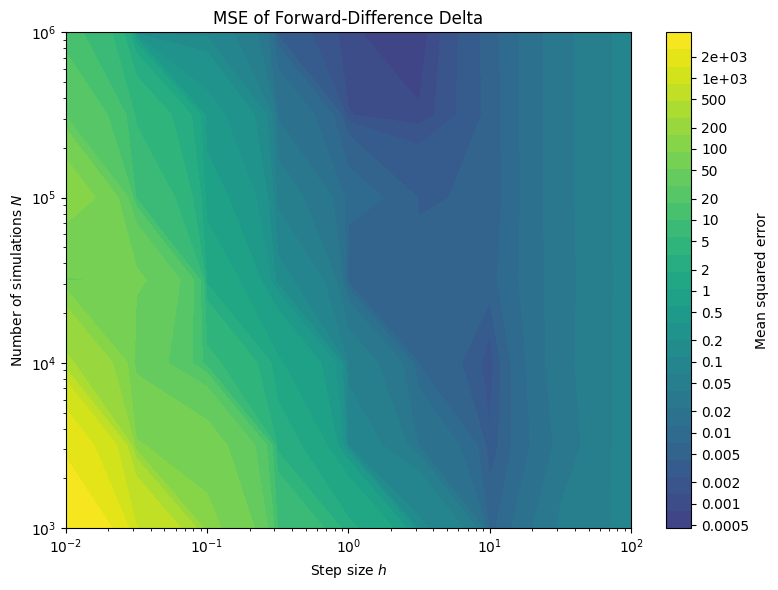

In [62]:
H, N = np.meshgrid(h_values, reps_values)

# Bounds of the plot
vmin = fd_mse[fd_mse > 0].min()
vmax = fd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,fd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Forward-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

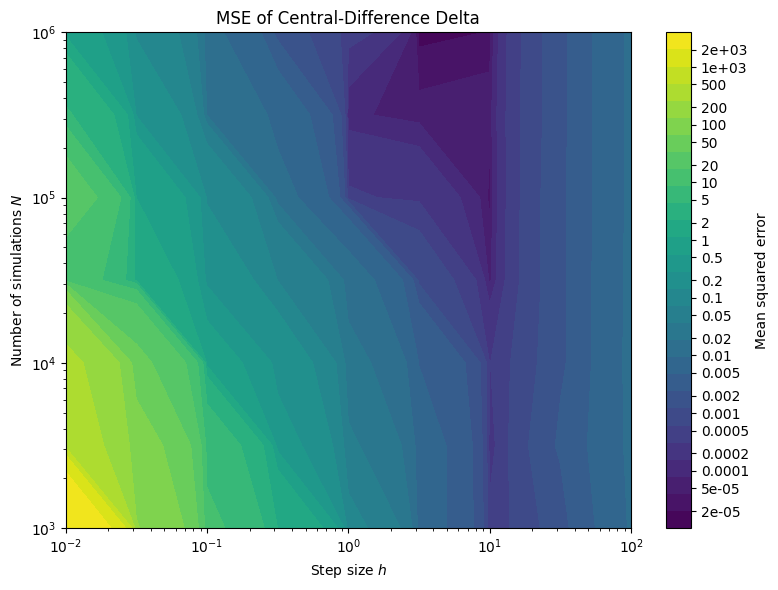

In [63]:
# Bounds for the plot
H, N = np.meshgrid(h_values, reps_values)

vmin = cd_mse[cd_mse > 0].min()
vmax = cd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,cd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Central-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

Notice that the levels of the contour plots should not be taken too seriously, as there are not enough empirical data points for the level of detail of the plots and interpolation is being used for unknown points. However, the main trends are visible and reliable: for both methods, under a fixed step size, increasing the number of simulations decreases the error, while at a fixed number of simulations we are left with a convex optimisation problem if we seek to find the optimal step size.

As exposed before, for independent simulations the leading-order MSE approximations are

$$
\operatorname{MSE}_{\mathrm{FD}}(N,h)
\approx
A_{\mathrm{FD}}h^2+\frac{B_{\mathrm{FD}}}{Nh^2},
$$

and

$$
\operatorname{MSE}_{\mathrm{CD}}(N,h)
\approx
A_{\mathrm{CD}}h^4+\frac{B_{\mathrm{CD}}}{Nh^2},
$$

where the constants do not depend on $N$ or $h$. The first term represents squared discretisation bias, while the second represents Monte Carlo variance. Therefore, for small $h$, the error is dominated by the term of order

$$
O\left(\frac{1}{Nh^2}\right),
$$

so increasing $N$ produces a visible reduction in error. For large $h$, the bias term dominates, with order

$$
O(h^2)
$$

for forward differences and

$$
O(h^4)
$$

for central differences. Consequently, in the large-$h$ region the contour levels become approximately vertical: changing $h$ has a substantial effect on the error, while increasing $n$ has comparatively little effect. These separate regions are visible in the above plots.

In addition, it is visible that the Central Difference method provides a lower error for each pair of parameter values. This is to be expected from the error analysis conducted.

Next, we empirically estimate the coefficients $A$ and $B$ in order to obtain a rule for the optimal value of $h$ as a function of $N$. For a European call, these coefficients could in principle be derived analytically from the Black-Scholes price derivatives and the moments of the discounted payoff. However, this approach would not generalise naturally to the exotic options considered later, for which closed-form prices, derivatives and payoff moments are generally unavailable. We therefore estimate the coefficients numerically, using a procedure that can later be applied consistently across different products. We first do so for the forward-difference method.

In [64]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 100

# Empirical MSE values
fd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_call_delta_fd_estimate(s,K,T,r,vol,reps_i,h_j)
            squared_errors[trial] = (delta_fd - real_delta)**2
        fd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = fd_mse_fit.ravel()

# MSE(N,h) ≈ A h^2 + B / (N h^2)
def fd_mse_model(x, A, B):
    N, h = x
    return A * h**2 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(fd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_fd, B_hat_fd = parameters

# Print results
print(f"Estimated A = {A_hat_fd:.6e}")
print(f"Estimated B = {B_hat_fd:.6e}")

Estimated A = 8.994326e-05
Estimated B = 5.475445e+02


These values are used below to define a function $h:\mathbb{N}\to\mathbb{R}_{>0}$ that estimates the optimal step size as a function of the number of simulations used in order to reduce the expected error of the approximation of the delta.

In [65]:
# Optimal h as a function of N (according to theory)
def h_opt_fd(N):
    return (B_hat_fd/(N*A_hat_fd))**(1/4)

We compute the optimal step size $h$ for values of $N$ tested in the above table to test the accuracy of this function qualitatively.

In [66]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_fd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_fd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_fd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_fd(1_000_000)}")

Optimal step size for N = 1,000 : 8.83309087003055
Optimal step size for N = 10,000 : 4.9672120253797525
Optimal step size for N = 100,000 : 2.793268592853488
Optimal step size for N = 1,000,000 : 1.570770362117812


From the plot 'MSE of Forward-Difference Delta', one can visually verify that the above estimations for the optimal step size are sufficiently accurate and on the correct order of magnitude.

We also approximate the optimal step size function for the Central difference method.

In [67]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 100

# Empirical MSE values
cd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_call_delta_cd_estimate(s,K,T,r,vol,reps_i,h_j)
            squared_errors[trial] = (delta_cd - real_delta)**2
        cd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = cd_mse_fit.ravel()

# MSE(N,h) ≈ A h^4 + B / (N h^2)
def cd_mse_model(x, A, B):
    N, h = x
    return A * h**4 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(cd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_cd, B_hat_cd = parameters

# Print results
print(f"Estimated A = {A_hat_cd:.6e}")
print(f"Estimated B = {B_hat_cd:.6e}")

Estimated A = 5.471527e-08
Estimated B = 1.716779e+02


In [68]:
# Optimal h as a function of N (according to theory)
def h_opt_cd(N):
    return (B_hat_cd/(2*N*A_hat_cd))**(1/6)

In [69]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_cd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_cd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_cd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_cd(1_000_000)}")

Optimal step size for N = 1,000 : 10.779434539953325
Optimal step size for N = 10,000 : 7.343943260999654
Optimal step size for N = 100,000 : 5.003370299330726
Optimal step size for N = 1,000,000 : 3.4087565034941814


The estimated function agrees well with the visual results from the plot 'MSE of Central-Difference Delta'.

We repeat the above process, this time using Common Random Numbers instead of independent random numbers in order to reduce the error for each pair of parameters. We adjust slightly the range of the parameter values.

In [70]:
# Values to investigate
reps_values = np.logspace(3, 6, 7, dtype=int)
h_values = np.logspace(-3, 1, 9)

In [71]:
trials = 5

# Rows correspond to reps, columns correspond to h
fd_crn_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd_crn = finite_difference.mc_call_delta_fd_estimate_crn(s,K,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_fd_crn - real_delta)**2
        fd_crn_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_crn_error_table = pd.DataFrame(fd_crn_mse, index=reps_values, columns=h_values)

fd_crn_error_table.index.name = "reps"
fd_crn_error_table.columns.name = "h"

display(fd_crn_error_table)

h,0.001000,0.003162,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000
reps,,,,,,,,,
1000,6.227731e-04,1.753292e-04,1.451828e-04,6.250915e-04,2.511350e-04,0.000352,0.000417,0.001073,0.005318
3162,1.510194e-04,1.642367e-04,4.334566e-05,4.031268e-05,1.277778e-04,0.000324,0.000298,0.000541,0.004225
10000,2.529175e-05,3.618177e-05,3.075441e-05,5.260325e-05,1.189454e-05,0.000085,0.000086,0.000739,0.004314
31622,1.756050e-05,1.204275e-05,3.642520e-06,1.579629e-05,2.279296e-05,0.000027,0.000043,0.000549,0.004943
100000,3.629875e-06,9.333223e-06,5.811337e-06,5.370343e-06,4.799842e-06,0.000007,0.000053,0.000523,0.004947
316227,6.073648e-07,7.917247e-07,8.927019e-07,1.934219e-07,1.024177e-06,0.000007,0.000058,0.000545,0.004803
1000000,7.770401e-07,1.756820e-07,2.232080e-07,2.997242e-07,1.432146e-07,0.000006,0.000058,0.000557,0.004871


In [72]:
trials = 5

# Rows correspond to reps, columns correspond to h
cd_crn_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd_crn = finite_difference.mc_call_delta_cd_estimate_crn(s,K,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_cd_crn - real_delta)**2
        cd_crn_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_crn_error_table = pd.DataFrame(cd_crn_mse, index=reps_values, columns=h_values)

cd_crn_error_table.index.name = "reps"
cd_crn_error_table.columns.name = "h"

display(cd_crn_error_table)

h,0.001000,0.003162,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000
reps,,,,,,,,,
1000,2.701510e-04,6.165191e-04,1.725750e-04,6.299952e-04,4.204934e-04,3.304691e-04,3.672205e-04,1.201896e-04,0.000535
3162,7.831815e-05,4.433127e-05,8.645452e-05,5.962099e-05,7.416130e-05,8.427241e-05,1.480412e-04,1.387485e-04,0.000203
10000,2.718195e-05,2.189495e-05,6.919705e-05,1.458728e-05,5.016925e-05,6.036432e-05,1.261806e-05,4.721410e-05,0.000041
31622,7.389693e-06,7.193020e-06,7.775785e-06,1.290184e-05,1.275036e-06,1.058914e-05,8.877839e-06,2.704237e-06,0.000075
100000,4.907991e-06,1.181751e-06,3.930449e-06,2.071726e-06,5.094516e-06,3.358640e-06,3.570147e-06,1.352430e-06,0.000023
316227,7.234298e-07,1.737201e-06,6.315275e-07,1.338819e-06,6.479032e-07,1.771298e-06,2.255103e-06,1.952403e-06,0.000027
1000000,3.544545e-07,1.676483e-07,1.882097e-07,4.664208e-07,3.909832e-07,1.211622e-07,4.130671e-07,1.688131e-07,0.000033


The results above show how the error only varies significantly along the reps axis, as variance dominates the error fluctuations on the $h$ axis. This applies to both the Forward and Central difference methods. Recall that this is because the use of common random numbers makes the covariance between the two perturbed estimators large and positive, preventing the variance from growing proportionally to $1/h^2$ as $h$ decreases. The MSE is approximately of the form

$$
\operatorname{MSE}_{\mathrm{FD,CRN}}(N,h)
\approx
Ah^2+\frac{B}{N}
$$

for the Forward difference method, and

$$
\operatorname{MSE}_{\mathrm{CD,CRN}}(N,h)
\approx
Ah^4+\frac{B}{N}
$$

for the Central difference method.

Therefore, for small enough values of $h$, the error no longer decays noticeably or reliably. Consequently, we do not derive functions to find the optimal values of $h$ as a function of $N$.

## Pathwise Differentiation

We approximate the delta of a European call option through the method of Pathwise differentation, and compare the estimates with the theoretical value.

In [73]:
# Parameters of the European call option
s = 100
K = 100
T = 1
r = 0.05
vol = 0.25
reps = 10000

In [74]:
# Theoretical delta
d1 = (np.log(s/K) + (r + (vol**2)/2) * T) / (vol * (T)**(1/2))
real_delta = norm.cdf(d1)

In [75]:
# Approximate delta (Pathwise differentiation)
delta_pw = pathwise.mc_call_delta_pw_estimate(s,K,T,r,vol,reps)

# Compute error
delta_pw_error = abs(delta_pw - real_delta)

# Print results
print(f"True delta: {real_delta}")
print(f"Estimated delta (Pathwise differentiation): {delta_pw} | Error: {delta_pw_error}")

True delta: 0.627409464153284
Estimated delta (Pathwise differentiation): 0.6269359317046168 | Error: 0.0004735324486672132


The approximation is close to the true value. We now investigate how much the RMSE scales as a function of the number of simulations. Theoretically, we expect a relationship of the form

$$
\mathrm{RMSE} \propto N^{-1/2}.
$$

Therefore, a log-log plot of RMSE against $N$ should show a linear relationship with an approximate best-fit slope of $-1/2$.

In [76]:
reps_values = [10, 30, 100, 300, 1_000, 3_000,10_000, 30_000, 100_000]
trials = 1000

rmse_values = []

# Compute RMSE for each value of reps
for reps in reps_values:
    squared_errors = []
    for _ in range(trials):
        delta_pw = pathwise.mc_call_delta_pw_estimate(s,K,T,r,vol,reps)
        squared_errors.append((delta_pw - real_delta)**2)
    rmse = np.sqrt(np.mean(squared_errors))
    rmse_values.append(rmse)

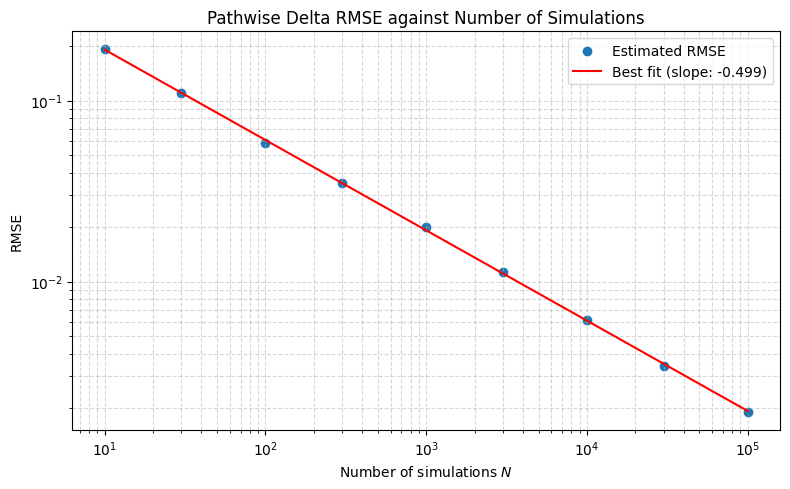

In [77]:
reps_array = np.array(reps_values)
rmse_array = np.array(rmse_values)

# Fit a straight line in log-log space
slope, intercept = np.polyfit(np.log(reps_array),np.log(rmse_array),1)
fitted_rmse = np.exp(intercept) * reps_array**slope

plt.figure(figsize=(8, 5))

# Add data points
plt.scatter(reps_array,rmse_array,label="Estimated RMSE")

# Add best-fit line
plt.plot(reps_array,fitted_rmse,linestyle="-",color="red", label=f"Best fit (slope: {slope:.3f})")

# Use a log-log scale on the grid
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of simulations $N$")
plt.ylabel("RMSE")
plt.title("Pathwise Delta RMSE against Number of Simulations")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

The above agrees with the theory. This means that for the method of Pathwise Differentiation, increasing the number of simulations decreases the error at a decreasing rate. 

We now study variance and MSE with varying values of moneyness ($S_0/K$) and volatility ($\sigma$). The effect of $N$ is known through

$$
\operatorname{MSE}(\widehat{\Delta}_{PW})
=
\frac{\operatorname{Var}(Y)}{N},
$$

where $Y$ denotes a single pathwise Delta observation. We therefore produce a grid over moneyness and volatility, allowing us to study how the remaining components of the estimator error vary across market regimes. The results can also be used to approximate the number of simulations required to achieve a target relative MSE if needed.

In [78]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [79]:
trials = 100
# Fix reps this time
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
pw_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + (vol_j**2)/2) * T) / (vol_j * (T)**(1/2))
        real_delta = norm.cdf(d1)
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_pw = pathwise.mc_call_delta_pw_estimate(s_i,K,T,r,vol_j,reps)
            trial_errors[trial] = (delta_pw - real_delta)**2
        pw_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
pw_error_table = pd.DataFrame(pw_mse, index=moneyness_values, columns=vol_values)

pw_error_table.index.name = "moneyness"
pw_error_table.columns.name = "vol"

display(pw_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000002,0.000009,0.000024,0.000045,0.000080,0.000101,0.000153,0.000150,0.000220,0.000286,...,0.000552,0.000617,0.000601,0.000544,0.000466,0.000464,0.000747,0.000646,0.000859,0.000790
0.725,0.000005,0.000021,0.000041,0.000063,0.000113,0.000152,0.000170,0.000198,0.000238,0.000270,...,0.000511,0.000551,0.000550,0.000640,0.000711,0.000742,0.000562,0.000750,0.000724,0.000617
0.750,0.000015,0.000036,0.000058,0.000109,0.000129,0.000191,0.000239,0.000204,0.000280,0.000293,...,0.000518,0.000481,0.000588,0.000636,0.000578,0.000450,0.000663,0.000808,0.000686,0.000702
0.775,0.000030,0.000075,0.000107,0.000126,0.000220,0.000224,0.000259,0.000313,0.000290,0.000368,...,0.000453,0.000453,0.000607,0.000728,0.000731,0.000611,0.000489,0.000698,0.000577,0.000781
0.800,0.000051,0.000101,0.000157,0.000195,0.000251,0.000237,0.000257,0.000333,0.000258,0.000373,...,0.000384,0.000669,0.000550,0.000727,0.000532,0.000633,0.000748,0.000716,0.000788,0.000675
0.825,0.000122,0.000160,0.000175,0.000203,0.000243,0.000331,0.000307,0.000320,0.000451,0.000380,...,0.000449,0.000565,0.000516,0.000577,0.000455,0.000694,0.000534,0.000766,0.000851,0.000735
0.850,0.000131,0.000150,0.000169,0.000249,0.000234,0.000347,0.000274,0.000347,0.000483,0.000334,...,0.000560,0.000651,0.000541,0.000577,0.000680,0.000626,0.000626,0.000659,0.000668,0.001072
0.875,0.000164,0.000248,0.000264,0.000248,0.000297,0.000394,0.000309,0.000389,0.000447,0.000380,...,0.000527,0.000529,0.000515,0.000636,0.000706,0.000724,0.000738,0.000935,0.000762,0.000677
0.900,0.000300,0.000303,0.000310,0.000421,0.000338,0.000305,0.000367,0.000403,0.000303,0.000469,...,0.000619,0.000592,0.000626,0.000541,0.000704,0.000854,0.000759,0.000570,0.000805,0.001202


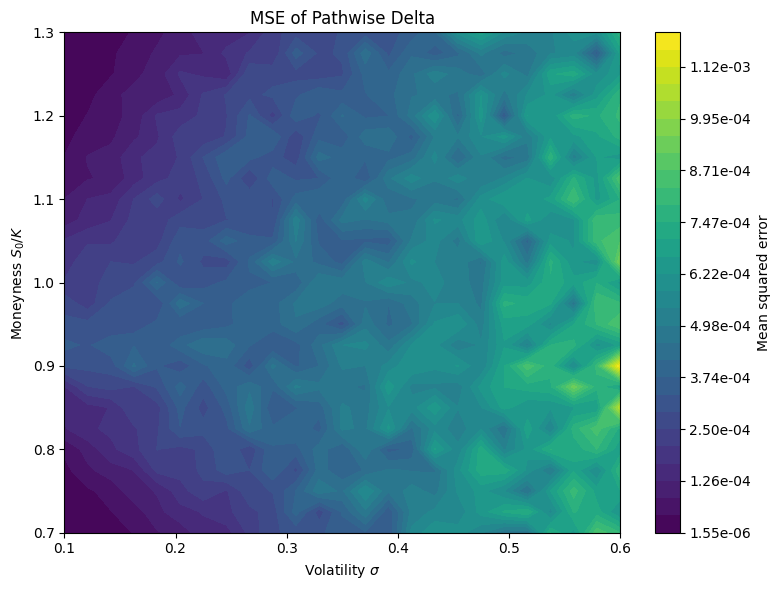

In [80]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(pw_mse.min(), pw_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,pw_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Pathwise Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

As expected, low moneyness results in low MSE due to the fact that most simulated derivatives are 0, so the estimated delta is very close to 0, as it should be for a deep OTM option. Similarly, high moneyness results in accurate estimations too because the possibility of contributing 0 to the estimated delta is unlikely, as it should be for deep ITM options. For ATM or close to ATM options, errors are larger. Larger volatility values result in larger errors, too, as the variance of the error is larger and so the absolute value of the error is, on average, larger. 

We confirm that the plot above approximates theoretical values well by plotting the same heatmap for the theoretical error formula, available for European call options but unavailable in general for other options.

In [81]:
# Define theoretical expected MSE of pathwise delta estimation
def theoretical_delta_pw_mse(s,K,T,r,vol,reps):
    d1 = (np.log(s/K) + (r + (vol**2)/2) * T) / (vol * (T)**(1/2))
    mse = (np.exp((vol**2) * T) * norm.cdf(d1 + vol*(T**(1/2))) - (norm.cdf(d1))**2) / reps
    return mse

In [82]:
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
theoretical_pw_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        theoretical_pw_mse[i, j] = theoretical_delta_pw_mse(moneyness_i*K,K,T,r,vol_j,reps)

# Convert the results into a labelled table
theoretical_pw_error_table = pd.DataFrame(theoretical_pw_mse, index=moneyness_values, columns=vol_values)

theoretical_pw_error_table.index.name = "moneyness"
theoretical_pw_error_table.columns.name = "vol"

display(theoretical_pw_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000002,0.000009,0.000026,0.000050,0.000081,0.000114,0.000149,0.000185,0.000219,0.000254,...,0.000447,0.000478,0.000511,0.000543,0.000577,0.000611,0.000646,0.000683,0.000721,0.000760
0.725,0.000005,0.000019,0.000044,0.000076,0.000111,0.000147,0.000184,0.000219,0.000253,0.000285,...,0.000468,0.000498,0.000529,0.000560,0.000593,0.000626,0.000660,0.000696,0.000733,0.000771
0.750,0.000013,0.000037,0.000070,0.000107,0.000146,0.000183,0.000219,0.000252,0.000284,0.000315,...,0.000486,0.000515,0.000545,0.000575,0.000606,0.000638,0.000671,0.000706,0.000742,0.000780
0.775,0.000029,0.000063,0.000104,0.000145,0.000183,0.000219,0.000253,0.000284,0.000314,0.000342,...,0.000502,0.000529,0.000557,0.000586,0.000616,0.000647,0.000680,0.000714,0.000749,0.000786
0.800,0.000055,0.000100,0.000144,0.000185,0.000221,0.000255,0.000285,0.000313,0.000339,0.000365,...,0.000514,0.000540,0.000567,0.000595,0.000624,0.000655,0.000686,0.000720,0.000755,0.000791
0.825,0.000095,0.000144,0.000188,0.000225,0.000258,0.000287,0.000313,0.000338,0.000361,0.000384,...,0.000523,0.000548,0.000574,0.000601,0.000630,0.000660,0.000691,0.000723,0.000758,0.000794
0.850,0.000146,0.000193,0.000231,0.000262,0.000289,0.000314,0.000336,0.000357,0.000378,0.000399,...,0.000529,0.000553,0.000579,0.000605,0.000633,0.000663,0.000693,0.000726,0.000759,0.000795
0.875,0.000202,0.000240,0.000269,0.000293,0.000315,0.000335,0.000353,0.000372,0.000390,0.000409,...,0.000533,0.000556,0.000581,0.000607,0.000635,0.000664,0.000694,0.000726,0.000760,0.000795
0.900,0.000252,0.000277,0.000298,0.000316,0.000332,0.000348,0.000365,0.000381,0.000397,0.000415,...,0.000534,0.000557,0.000582,0.000607,0.000634,0.000663,0.000693,0.000725,0.000758,0.000794


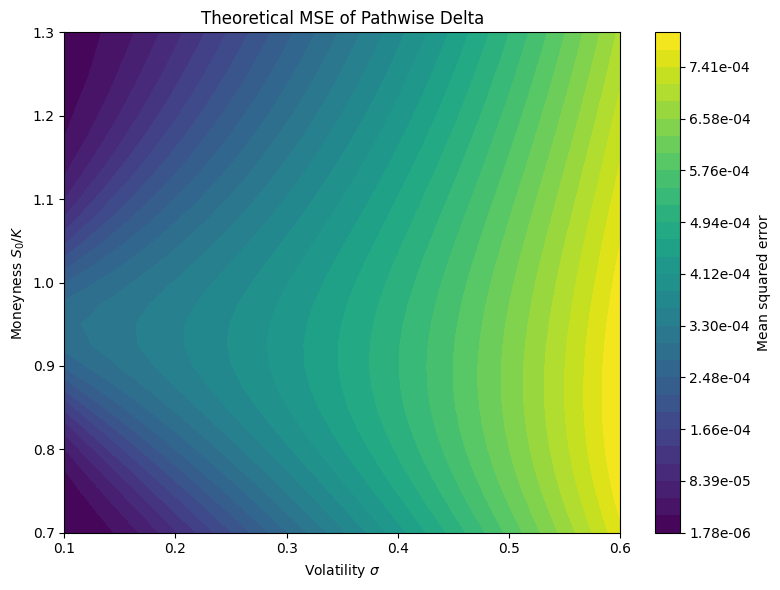

In [83]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(theoretical_pw_mse.min(), theoretical_pw_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,theoretical_pw_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("Theoretical MSE of Pathwise Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

A visual comparison of both tables suggests the error of the estimations is cose to as expected, suggesting the implementation and error analysis is correct.

We now compute the relative MSE of the empirical delta estimation to assess the appropriateness of the Pathwise derivative method across moneyness and volatility values.

In [84]:
# Rows correspond to moneyness, columns correspond to vol
pw_rel_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    for j,vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + (vol_j**2)/2) * T) / (vol_j * (T)**(1/2))
        real_delta = norm.cdf(d1)
        estimation_mse = pw_mse[i, j]
        rel_mse = estimation_mse/(real_delta**2)
        pw_rel_mse[i, j] = rel_mse

# Convert the results into a labelled table
pw_rel_error_table = pd.DataFrame(pw_rel_mse, index=moneyness_values, columns=vol_values)

pw_rel_error_table.index.name = "moneyness"
pw_rel_error_table.columns.name = "vol"

display(pw_rel_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.946909,0.210822,0.072819,0.035725,0.024698,0.015555,0.013701,0.008816,0.009206,0.009029,...,0.006315,0.006350,0.005616,0.004663,0.003687,0.003411,0.005138,0.004173,0.005234,0.004556
0.725,0.317752,0.100327,0.039374,0.020067,0.016686,0.012662,0.009089,0.007428,0.006720,0.006036,...,0.004823,0.004739,0.004358,0.004697,0.004868,0.004764,0.003399,0.004293,0.003939,0.003197
0.750,0.150458,0.045384,0.019920,0.015589,0.009907,0.009189,0.008031,0.005129,0.005566,0.004793,...,0.004096,0.003515,0.003995,0.004050,0.003465,0.002550,0.003564,0.004143,0.003358,0.003292
0.775,0.057470,0.028941,0.014934,0.008920,0.009470,0.006642,0.005748,0.005499,0.004209,0.004538,...,0.003045,0.002846,0.003587,0.004066,0.003872,0.003084,0.002359,0.003226,0.002562,0.003340
0.800,0.023626,0.014010,0.010080,0.007386,0.006476,0.004557,0.003941,0.004227,0.002806,0.003564,...,0.002225,0.003664,0.002859,0.003597,0.002517,0.002873,0.003262,0.003012,0.003199,0.002653
0.825,0.017049,0.009207,0.005712,0.004451,0.003992,0.004350,0.003383,0.003044,0.003806,0.002892,...,0.002268,0.002723,0.002382,0.002553,0.001940,0.002854,0.002122,0.002951,0.003180,0.002667
0.850,0.006601,0.004071,0.003069,0.003399,0.002581,0.003249,0.002248,0.002551,0.003236,0.002067,...,0.002498,0.002794,0.002237,0.002307,0.002632,0.002348,0.002284,0.002337,0.002307,0.003611
0.875,0.003519,0.003552,0.002898,0.002239,0.002314,0.002736,0.001955,0.002266,0.002432,0.001950,...,0.002094,0.002039,0.001923,0.002311,0.002496,0.002498,0.002484,0.003074,0.002449,0.002130
0.900,0.003172,0.002543,0.002211,0.002662,0.001945,0.001629,0.001836,0.001910,0.001370,0.002030,...,0.002213,0.002065,0.002131,0.001800,0.002293,0.002724,0.002372,0.001744,0.002419,0.003545


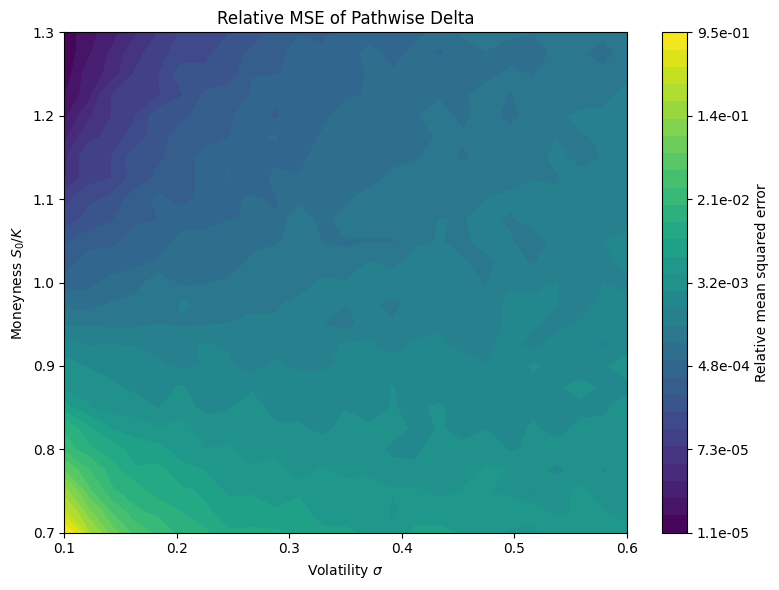

In [85]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

# Use only positive, finite values to define the logarithmic scale
positive_values = pw_rel_mse[
    np.isfinite(pw_rel_mse) & (pw_rel_mse > 0)
]

vmin = positive_values.min()
vmax = positive_values.max()

levels = np.geomspace(vmin, vmax, 30)

plt.figure(figsize=(8, 6))

contour = plt.contourf(VOL,MONEYNESS,pw_rel_mse,levels=levels,norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("Relative MSE of Pathwise Delta")

ticks = np.geomspace(vmin, vmax, 7)
cbar = plt.colorbar(contour, ticks=ticks, format="%.1e")
cbar.set_label("Relative mean squared error")

plt.tight_layout()
plt.show()

We observe that the relative error becomes larger at lower moneyness values. This is to be expected, as lower moneyness values result in lower values of delta, while the expected error of the approximation does not decay as fast due to the variance of the estimations. Additionally, larger volatility results in a larger error, as explained above.

As a final check, we ensure that the Pathwise Differentiation method converges to the Forward Difference method under Common Random Numbers as $h \to 0$.

In [86]:
reps_values = [100,1_000,10_000,100_000]
h_values = np.logspace(0,-8,11)

fd_pw_difference = np.empty((len(reps_values), len(h_values)))

# Populate table with differences
for i, reps_i in enumerate(reps_values):
    # Same sample used by PW and by FD for every h
    Z = np.random.standard_normal(reps_i)
    pw_delta = pathwise.mc_call_delta_pw_estimate(s,K,T,r,vol,reps_i,Z)
    for j, h_j in enumerate(h_values):
        fd_delta = finite_difference.mc_call_delta_fd_estimate_crn(s,K,T,r,vol,reps_i,h_j,Z)
        fd_pw_difference[i, j] = abs(fd_delta - pw_delta)

fd_pw_difference_table = pd.DataFrame(fd_pw_difference,index=reps_values,columns=h_values)

fd_pw_difference_table.index.name = "reps"
fd_pw_difference_table.columns.name = "h"

display(fd_pw_difference_table)



h,1.000000e+00,1.584893e-01,2.511886e-02,3.981072e-03,6.309573e-04,1.000000e-04,1.584893e-05,2.511886e-06,3.981072e-07,6.309573e-08,1.000000e-08
reps,,,,,,,,,,,
100,0.008413,4.884981e-15,1.956213e-13,5.726530e-13,7.023160e-12,3.635436e-11,3.380065e-10,8.837804e-10,1.492643e-08,5.007777e-08,5.174697e-07
1000,0.010971,3.063612e-03,1.791358e-04,5.662137e-14,1.763589e-12,2.976730e-12,8.835932e-11,1.401274e-09,5.000514e-09,3.321638e-08,5.107411e-07
10000,0.008372,1.544299e-03,3.186264e-04,1.311237e-04,9.946821e-12,4.553546e-11,7.350565e-12,1.800657e-09,1.416361e-08,3.941902e-08,1.122202e-07
100000,0.007243,1.158088e-03,1.835229e-04,2.747426e-05,7.900902e-12,4.774803e-11,7.126211e-11,1.663786e-09,1.755929e-08,1.450343e-07,9.410584e-08


The close agreement between the CRN finite-difference and pathwise estimators can occur even for relatively large values of $h$, such as $h=1$. This is a consequence of the piecewise-linear European call payoff. For any simulated path that remains out of the money after the spot perturbation, both estimators contribute zero. For any path that remains in the money, the payoff is linear in the terminal stock price, so the CRN finite-difference quotient is exactly equal to the corresponding pathwise contribution.

The two estimators differ only for paths whose terminal price crosses the strike after the perturbation:

$$
S_T(S_0) \leq K < S_T(S_0+h).
$$

Depending on the particular simulated sample, there may be very few or even no such paths when $h=1$, especially for small $N$, producing near-perfect agreement immediately. As $h \to 0$, the set of crossing paths becomes progressively smaller and, for any fixed finite sample, eventually disappears. Consequently,

$$
\widehat{\Delta}_{\mathrm{FD,CRN}}(h)
\longrightarrow
\widehat{\Delta}_{\mathrm{PW}}
\qquad \text{as } h \to 0,
$$

up to numerical precision.

## Likelihood-Ratio

Finally, we approximate the delta of a European call through the Likelihood-Ratio method. We begin by a simple approximation to verify the correct behaviour of the estimator.

In [87]:
# Parameters of the European call option
s = 100
K = 100
T = 1
r = 0.05
vol = 0.25
reps = 10000

In [88]:
# Theoretical delta
d1 = (np.log(s/K) + (r + (vol**2)/2) * T) / (vol * (T)**(1/2))
real_delta = norm.cdf(d1)

In [89]:
# Approximate delta (Likelihood ratio)
delta_lr = likelihood_ratio.mc_call_delta_lr_estimate(s,K,T,r,vol,reps)

# Compute error
delta_lr_error = abs(delta_lr - real_delta)

# Print results
print(f"True delta: {real_delta}")
print(f"Estimated delta (Likelihood ratio): {delta_lr} | Error: {delta_lr_error}")

True delta: 0.627409464153284
Estimated delta (Likelihood ratio): 0.6110734269704908 | Error: 0.016336037182793195


This suggests the implementation is likely correct. Next, as for the Pathwise estimator, we investigate how the MSE changes as a function of the moneyness and the volatility of the underlying asset. 

In [90]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [91]:
trials = 100
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
lr_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + (vol_j**2)/2) * T) / (vol_j * (T)**(1/2))
        real_delta = norm.cdf(d1)
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_lr = likelihood_ratio.mc_call_delta_lr_estimate(s_i,K,T,r,vol_j,reps)
            trial_errors[trial] = (delta_lr - real_delta)**2
        lr_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
lr_error_table = pd.DataFrame(lr_mse, index=moneyness_values, columns=vol_values)

lr_error_table.index.name = "moneyness"
lr_error_table.columns.name = "vol"

display(lr_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000002,0.000018,0.000056,0.000107,0.000213,0.000353,0.000466,0.000474,0.000657,0.000616,...,0.001341,0.001484,0.001887,0.001558,0.002483,0.001664,0.002022,0.002851,0.003030,0.003033
0.725,0.000010,0.000049,0.000096,0.000191,0.000242,0.000232,0.000428,0.000580,0.000794,0.000897,...,0.001868,0.001613,0.001742,0.002318,0.001930,0.001589,0.002474,0.002806,0.002376,0.003017
0.750,0.000032,0.000068,0.000183,0.000356,0.000441,0.000502,0.000624,0.000759,0.000780,0.000892,...,0.001927,0.001800,0.001824,0.002264,0.002483,0.002772,0.002051,0.002715,0.002109,0.002946
0.775,0.000065,0.000149,0.000311,0.000315,0.000477,0.000898,0.000806,0.000921,0.000899,0.001237,...,0.002169,0.001595,0.002199,0.002401,0.002107,0.002390,0.002484,0.002601,0.003269,0.003455
0.800,0.000128,0.000225,0.000457,0.000553,0.000725,0.000994,0.000765,0.001071,0.001131,0.001118,...,0.002453,0.002162,0.002575,0.002231,0.002143,0.002391,0.003734,0.003745,0.003081,0.003017
0.825,0.000304,0.000358,0.000620,0.000695,0.000990,0.000815,0.000853,0.001161,0.001506,0.001025,...,0.001629,0.001845,0.002662,0.002974,0.003210,0.003352,0.002750,0.002757,0.004150,0.003060
0.850,0.000398,0.000528,0.000514,0.000860,0.000837,0.000949,0.000944,0.001398,0.001497,0.001967,...,0.002138,0.002900,0.003679,0.002803,0.002196,0.002344,0.002596,0.002907,0.003421,0.003168
0.875,0.000603,0.000633,0.001047,0.000922,0.001125,0.001333,0.001309,0.001634,0.001683,0.001569,...,0.002256,0.002395,0.003024,0.002573,0.002961,0.003511,0.003239,0.002786,0.003596,0.003064
0.900,0.000916,0.001171,0.001183,0.001147,0.001592,0.001653,0.001431,0.001750,0.001604,0.002140,...,0.002237,0.002922,0.002537,0.002333,0.002606,0.003077,0.003529,0.003511,0.003883,0.003484


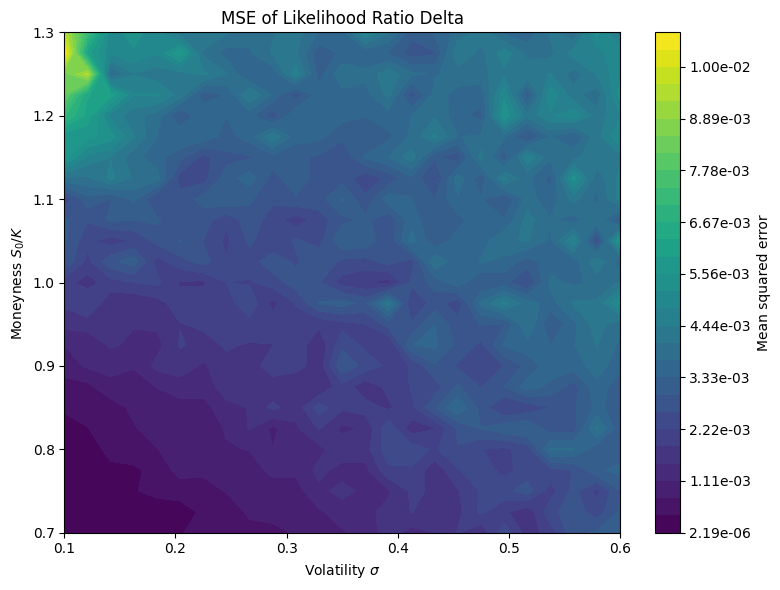

In [92]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_mse.min(), lr_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood Ratio Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

The behaviour for deep OTM options is similar for the Pathwise Differentiation and the Likelihood-Ratio methods. However, for deep ITM options, their behaviours are almost inverted. In this case, lower volatility results in larger MSE instead. 

This is because for deep ITM options, exercise occurs with probability close to one, so the discounted payoff is approximately constant, and in the Likelihood-Ratio estimator, this constant is multiplied by the score $Z/(S_0\sigma\sqrt{T})$, whose variance grows like $1/\sigma^2$ as volatility decreases. Hence, unlike the pathwise estimator, the LR estimator becomes increasingly noisy in the low-volatility, high-moneyness region.

We repeat the analysis but consider this time Relative MSE as a function of the same two parameters.

In [93]:
# Rows correspond to moneyness, columns correspond to vol
lr_rel_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    for j,vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + (vol_j**2)/2) * T) / (vol_j * (T)**(1/2))
        real_delta = norm.cdf(d1)
        estimation_mse = lr_mse[i, j]
        rel_mse = estimation_mse/(real_delta**2)
        lr_rel_mse[i, j] = rel_mse

# Convert the results into a labelled table
lr_rel_error_table = pd.DataFrame(lr_rel_mse, index=moneyness_values, columns=vol_values)

lr_rel_error_table.index.name = "moneyness"
lr_rel_error_table.columns.name = "vol"

display(lr_rel_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.341674,0.418341,0.168978,0.084929,0.065688,0.054118,0.041843,0.027859,0.027459,0.019447,...,0.015352,0.015271,0.017649,0.013350,0.019651,0.012239,0.013903,0.018411,0.018454,0.017494
0.725,0.660854,0.239438,0.091742,0.061188,0.035739,0.019273,0.022844,0.021806,0.022458,0.020028,...,0.017621,0.013884,0.013792,0.017019,0.013215,0.010207,0.014973,0.016065,0.012919,0.015630
0.750,0.317300,0.085574,0.062717,0.050935,0.033821,0.024187,0.020955,0.019105,0.015508,0.014586,...,0.015226,0.013144,0.012402,0.014412,0.014879,0.015706,0.011031,0.013912,0.010324,0.013821
0.775,0.125183,0.057231,0.043583,0.022204,0.020515,0.026631,0.017866,0.016160,0.013026,0.015255,...,0.014579,0.010020,0.012997,0.013410,0.011168,0.012067,0.011988,0.012027,0.014524,0.014783
0.800,0.059634,0.031187,0.029331,0.020943,0.018707,0.019147,0.011704,0.013619,0.012327,0.010700,...,0.014211,0.011834,0.013374,0.011044,0.010143,0.010853,0.016296,0.015749,0.012510,0.011850
0.825,0.042270,0.020588,0.020235,0.015275,0.016264,0.010715,0.009384,0.011047,0.012697,0.007798,...,0.008234,0.008893,0.012282,0.013170,0.013682,0.013784,0.010932,0.010613,0.015500,0.011101
0.850,0.019989,0.014335,0.009338,0.011751,0.009245,0.008893,0.007747,0.010275,0.010025,0.012160,...,0.009539,0.012438,0.015212,0.011199,0.008497,0.008796,0.009466,0.010311,0.011820,0.010674
0.875,0.012916,0.009074,0.011485,0.008336,0.008781,0.009261,0.008269,0.009527,0.009162,0.008046,...,0.008968,0.009226,0.011305,0.009350,0.010474,0.012107,0.010901,0.009159,0.011558,0.009636
0.900,0.009701,0.009815,0.008435,0.007255,0.009169,0.008820,0.007167,0.008298,0.007250,0.009266,...,0.008002,0.010191,0.008640,0.007764,0.008485,0.009809,0.011021,0.010754,0.011667,0.010275


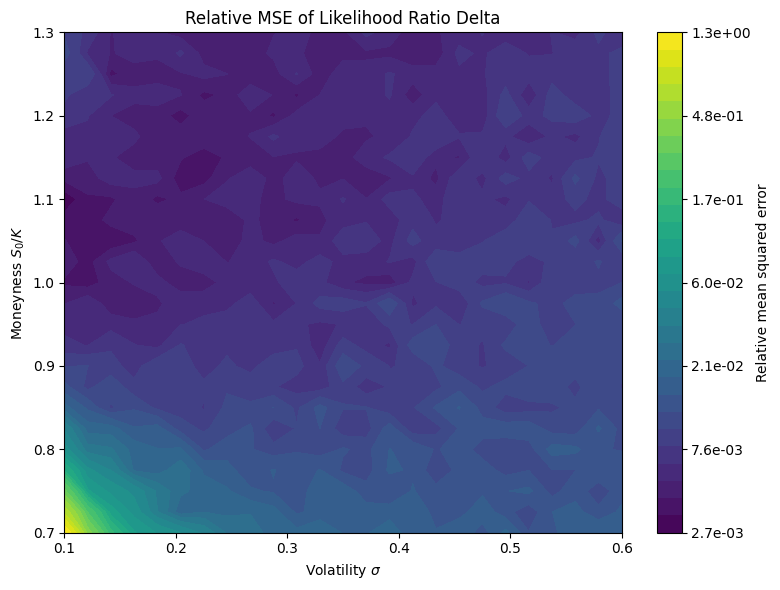

In [94]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

# Use only positive, finite values to define the logarithmic scale
positive_values = lr_rel_mse[
    np.isfinite(lr_rel_mse) & (lr_rel_mse > 0)
]

vmin = positive_values.min()
vmax = positive_values.max()

levels = np.geomspace(vmin, vmax, 30)

plt.figure(figsize=(8, 6))

contour = plt.contourf(VOL,MONEYNESS,lr_rel_mse,levels=levels,norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("Relative MSE of Likelihood Ratio Delta")

ticks = np.geomspace(vmin, vmax, 7)
cbar = plt.colorbar(contour, ticks=ticks, format="%.1e")
cbar.set_label("Relative mean squared error")

plt.tight_layout()
plt.show()

An inverted pattern to the above is visible, with improvements for ATM options. There is high relative variance at low volatility - low moneyness, implying that even though absolute MSE is lower in this region, its Delta is as well, and the relative error is in fact worse than in the low volatility - high moneyness region. 

Finally, we implement payoff centring in order to reduce the MSE of the approximations obtained via the likelihood-ratio method. Recall that, writing the LR estimator as $HW$, where $H$ is the discounted payoff and $W$ is the score, we have $\mathbb{E}[W]=0$. Therefore, replacing $H$ by $H-c$ preserves unbiasedness:

$$
\mathbb{E}[(H-c)W]=\mathbb{E}[HW].
$$

The variance-minimising choice is

$$
c^*=\frac{\mathbb{E}[HW^2]}{\mathbb{E}[W^2]},
$$

which, for the Black-Scholes Delta score $W=Z/(S_0\sigma\sqrt{T})$, can equivalently be written as

$$
c^*=\frac{\mathbb{E}[HZ^2]}{\mathbb{E}[Z^2]}.
$$

We implement this below.

In [95]:
# Define function to estimate optimal value of c
def optimal_c(s,K,T,r,vol,reps):
    Z = np.random.standard_normal(reps)
    paths = path_simulator.one_step_paths(s,T,r,vol,reps,Z)
    call_payoffs = payoffs.call_payoff(paths,K)
    H = np.exp(-r*T) * np.where(call_payoffs > 0, call_payoffs, 0)
    c = np.sum(H * Z**2) / np.sum(Z**2)
    return c

In [96]:
trials = 100
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
lr_centred_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + (vol_j**2)/2) * T) / (vol_j * (T)**(1/2))
        real_delta = norm.cdf(d1)
        trial_errors = np.empty(trials)
        c = optimal_c(s_i,K,T,r,vol_j,reps)
        for trial in range(trials):
            delta_lr_centred = likelihood_ratio.mc_call_delta_lr_centred_estimate(s_i,K,T,r,vol_j,reps,c)
            trial_errors[trial] = (delta_lr_centred - real_delta)**2
        lr_centred_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
lr_centred_error_table = pd.DataFrame(lr_centred_mse, index=moneyness_values, columns=vol_values)

lr_centred_error_table.index.name = "moneyness"
lr_centred_error_table.columns.name = "vol"

display(lr_centred_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000003,0.000024,0.000046,0.000091,0.000194,0.000199,0.000276,0.000410,0.000638,0.000406,...,0.001012,0.001265,0.001415,0.001448,0.001121,0.001840,0.001838,0.001951,0.001744,0.001851
0.725,0.000008,0.000044,0.000123,0.000142,0.000195,0.000358,0.000305,0.000389,0.000604,0.000777,...,0.001319,0.001398,0.001490,0.001541,0.001683,0.001682,0.001811,0.001611,0.001924,0.002082
0.750,0.000028,0.000073,0.000130,0.000274,0.000336,0.000389,0.000591,0.000557,0.000511,0.000660,...,0.001288,0.001425,0.001113,0.001498,0.001603,0.001696,0.001903,0.002133,0.002255,0.001789
0.775,0.000057,0.000131,0.000221,0.000315,0.000470,0.000286,0.000888,0.000932,0.000571,0.000764,...,0.001165,0.001853,0.001384,0.001635,0.001893,0.001414,0.002320,0.002538,0.001710,0.002528
0.800,0.000120,0.000229,0.000217,0.000318,0.000486,0.000714,0.000675,0.000672,0.000856,0.000929,...,0.001614,0.001406,0.001342,0.002011,0.001743,0.002374,0.001796,0.002080,0.002641,0.002016
0.825,0.000273,0.000336,0.000399,0.000471,0.000626,0.000640,0.000801,0.000708,0.000926,0.000923,...,0.001312,0.001396,0.001720,0.001797,0.001557,0.001567,0.002043,0.001844,0.001904,0.001941
0.850,0.000357,0.000482,0.000585,0.000600,0.000838,0.000656,0.000683,0.000889,0.000752,0.001132,...,0.001454,0.001339,0.001792,0.001597,0.002016,0.002203,0.002033,0.002440,0.002551,0.002281
0.875,0.000336,0.000538,0.000581,0.000871,0.000824,0.000798,0.000852,0.000995,0.001080,0.001058,...,0.001234,0.001927,0.001769,0.001535,0.001889,0.002421,0.001995,0.002229,0.002835,0.002823
0.900,0.000495,0.000614,0.000892,0.000633,0.000788,0.001014,0.001255,0.001037,0.001344,0.000977,...,0.001589,0.001851,0.001836,0.001768,0.002210,0.001708,0.002041,0.002915,0.003610,0.002413


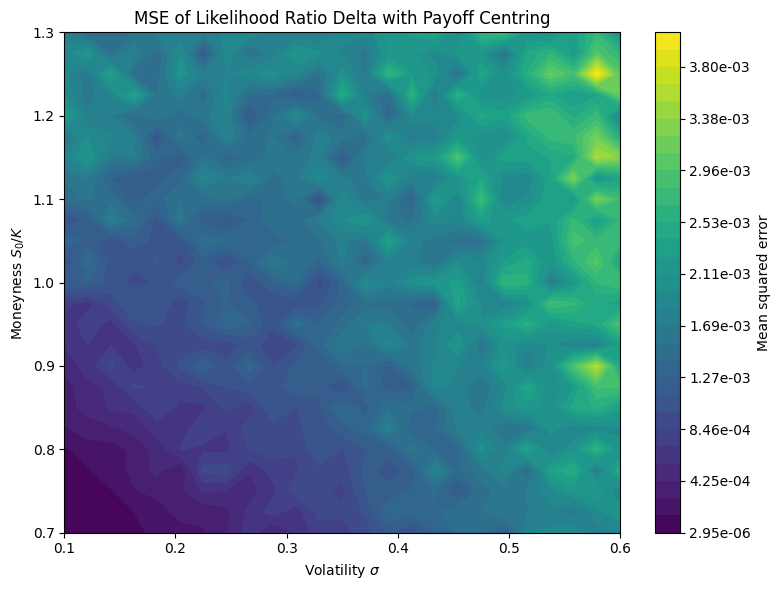

In [97]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_centred_mse.min(), lr_centred_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_centred_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood Ratio Delta with Payoff Centring")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

We observe lower MSE across almost the entire grid compared to the results without Payoff centring. In particular, the variance of high moneyness - low volatility Delta estimations is lower here (about 4 times lower). The minimum MSE is observed at low moneyness - low volatility values. This suggests that Payoff centring has been effectively implemented and works as expected.

We plot a similar heatmap of the ratio $\frac{\operatorname{MSE}(\text{LR with centring})}{\operatorname{MSE}(\text{LR without centring})}$ to observe the effect of this method in reducing the MSE.

In [98]:
# Rows correspond to moneyness, columns correspond to vol
lr_mse_ratio = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    for j,vol_j in enumerate(vol_values):
        ratio = lr_centred_mse[i,j]/lr_mse[i,j]
        lr_mse_ratio[i,j] = ratio

# Convert the results into a labelled table
lr_mse_ratio_error_table = pd.DataFrame(lr_mse_ratio, index=moneyness_values, columns=vol_values)

lr_mse_ratio_error_table.index.name = "moneyness"
lr_mse_ratio_error_table.columns.name = "vol"

display(lr_mse_ratio_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.348817,1.296965,0.832471,0.851826,0.910472,0.563807,0.591312,0.866411,0.972143,0.659297,...,0.754557,0.852431,0.749930,0.929633,0.451297,1.106012,0.908658,0.684173,0.575774,0.610221
0.725,0.782104,0.892458,1.273418,0.744439,0.803691,1.543806,0.712197,0.670810,0.760132,0.866010,...,0.706339,0.866312,0.855577,0.664862,0.871985,1.058432,0.731800,0.574242,0.809737,0.690211
0.750,0.888611,1.066205,0.707165,0.769948,0.763491,0.774790,0.946660,0.733390,0.655647,0.739452,...,0.668573,0.791814,0.609898,0.661912,0.645713,0.612100,0.927834,0.785504,1.069201,0.607229
0.775,0.873383,0.881952,0.709916,1.000463,0.985355,0.318523,1.102033,1.012623,0.635405,0.618068,...,0.537034,1.162387,0.629365,0.680789,0.898479,0.591600,0.933737,0.975775,0.523084,0.731701
0.800,0.938216,1.018933,0.476070,0.575932,0.669541,0.718583,0.882326,0.627333,0.757055,0.830293,...,0.658087,0.650502,0.521243,0.901189,0.813352,0.992664,0.481013,0.555373,0.857297,0.668405
0.825,0.898647,0.938103,0.643179,0.677094,0.632150,0.785163,0.939614,0.610479,0.615098,0.900563,...,0.805775,0.756795,0.646077,0.604267,0.484950,0.467635,0.742930,0.669103,0.458663,0.634439
0.850,0.897011,0.912177,1.137491,0.698001,1.001692,0.691061,0.722750,0.635548,0.502082,0.575276,...,0.679953,0.461798,0.487205,0.569793,0.917903,0.939870,0.783142,0.839337,0.745743,0.719971
0.875,0.556077,0.849996,0.554485,0.944307,0.732044,0.598626,0.650825,0.608719,0.641874,0.674169,...,0.546873,0.804622,0.585071,0.596539,0.638043,0.689452,0.615776,0.799892,0.788280,0.921325
0.900,0.540900,0.524260,0.754322,0.552041,0.494874,0.613295,0.876488,0.592498,0.837633,0.456405,...,0.710334,0.633691,0.723842,0.757734,0.847975,0.555040,0.578362,0.830285,0.929768,0.692761


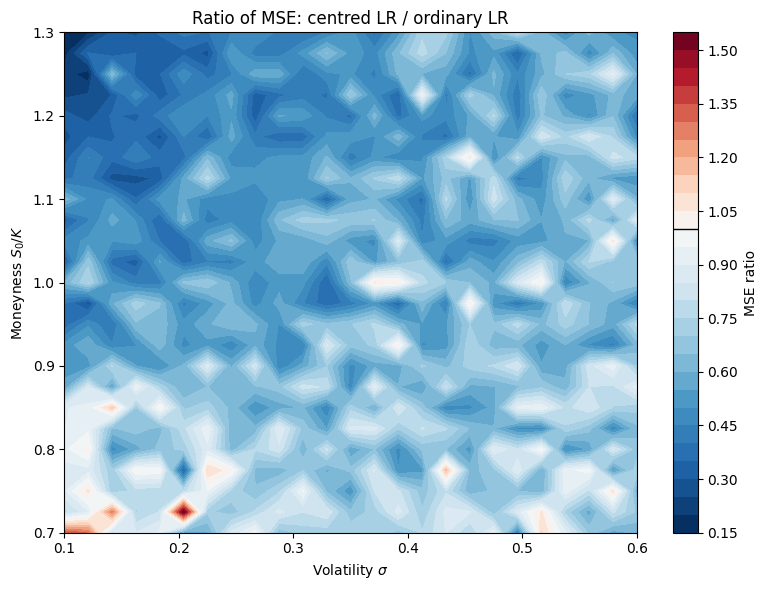

In [99]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Centre the colormap at ratio = 1
map_norm = TwoSlopeNorm(vmin=lr_mse_ratio.min(),vcenter=1.0,vmax=lr_mse_ratio.max())

contour = plt.contourf(VOL,MONEYNESS,lr_mse_ratio,levels=30,cmap="RdBu_r",norm=map_norm)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("Ratio of MSE: centred LR / ordinary LR")

cbar = plt.colorbar(contour, format="%.2f")
cbar.set_label("MSE ratio")
cbar.ax.axhline(1.0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

We observe larger improvements in areas of the grid where the LR method shows greater variance, and no improvements in areas where the estimations already showed low variance. This makes Payoff centring a potentially attractive choice, despite some worse results on the bottom-left corner of the grid. Some large-ratio areas outside the bottom-left corner may be due to the random nature of the experiment.

To close this Notebook, we perform a comparative analysis of the three methods implemented for the delta of European call options. We consider two things: the MSE using the best variant of each method, and the factor Runtime x MSE, which accounts for the computational cost of carrying out simulations.

We begin by considering these on the same Moneyness-Volatility grid as above. We consider the Central Difference method with Common Random Numbers and a constant step size relative to the spot price $S_0$ (we do not consider the optimal $h$ as a function of $N$ because that would make computations too expensive and provide little improvement to results, given CRN already significantly stabilises results across h values), the Pathwise Differentiation method, and the Likelihood-Ratio method with Payoff Centring. We consider the same Moneyness-Volatility grid as above.

The choice of the parameter relative_h was made by considering the optimal value of $h$ for an option with parameter values at the midpoint of the grid and $1,000$ reps. It was made this way in order not to favour large or small parameter values in a particular way.

In [100]:
trials = 100
reps = 1_000
pilot_reps = 1_000

relative_h = 0.1

shape = (len(moneyness_values), len(vol_values))

# MSE arrays
cd_crn_mse = np.empty(shape)
pw_mse = np.empty(shape)
lr_centred_mse = np.empty(shape)

# Estimator runtime arrays
cd_crn_runtime = np.empty(shape)
pw_runtime = np.empty(shape)
lr_centred_runtime = np.empty(shape)

# Separate runtime required to estimate c
lr_c_runtime = np.empty(shape)

for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    h_i = relative_h * s_i

    for j, vol_j in enumerate(vol_values):
        d1 = (np.log(moneyness_i) + (r + 0.5 * vol_j**2) * T) / (vol_j * np.sqrt(T))
        real_delta = norm.cdf(d1)

        start = time.perf_counter()
        c_ij = optimal_c(s_i, K, T, r, vol_j, pilot_reps)
        lr_c_runtime[i, j] = time.perf_counter() - start

        cd_trial_errors = np.empty(trials)
        pw_trial_errors = np.empty(trials)
        lr_trial_errors = np.empty(trials)

        cd_trial_runtimes = np.empty(trials)
        pw_trial_runtimes = np.empty(trials)
        lr_trial_runtimes = np.empty(trials)

        for trial in range(trials):
            start = time.perf_counter()
            delta_cd_crn = finite_difference.mc_call_delta_cd_estimate_crn(s_i, K, T, r, vol_j, reps, h_i)
            cd_trial_runtimes[trial] = time.perf_counter() - start

            start = time.perf_counter()
            delta_pw = pathwise.mc_call_delta_pw_estimate(s_i, K, T, r, vol_j, reps)
            pw_trial_runtimes[trial] = time.perf_counter() - start

            start = time.perf_counter()
            delta_lr_centred = likelihood_ratio.mc_call_delta_lr_centred_estimate(s_i, K, T, r, vol_j, reps, c_ij)
            lr_trial_runtimes[trial] = time.perf_counter() - start

            cd_trial_errors[trial] = (delta_cd_crn - real_delta)**2
            pw_trial_errors[trial] = (delta_pw - real_delta)**2
            lr_trial_errors[trial] = (delta_lr_centred - real_delta)**2

        cd_crn_mse[i, j] = np.mean(cd_trial_errors)
        pw_mse[i, j] = np.mean(pw_trial_errors)
        lr_centred_mse[i, j] = np.mean(lr_trial_errors)

        cd_crn_runtime[i, j] = np.mean(cd_trial_runtimes)
        pw_runtime[i, j] = np.mean(pw_trial_runtimes)
        lr_centred_runtime[i, j] = np.mean(lr_trial_runtimes)

In [101]:
# MSE table
mse_rows = []

# Populate table with data obtained
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        mse_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": cd_crn_mse[i, j],
            "Pathwise": pw_mse[i, j],
            "Centred LR": lr_centred_mse[i, j]
        })

mse_comparison_table = pd.DataFrame(mse_rows).set_index(["moneyness", "volatility"])
mse_comparison_table["Best method"] = mse_comparison_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)

display(mse_comparison_table)

CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.000010  0.000002    0.000003     Pathwise
          0.120833       0.000040  0.000011    0.000026     Pathwise
          0.141667       0.000082  0.000023    0.000064     Pathwise
          0.162500       0.000100  0.000060    0.000093     Pathwise
          0.183333       0.000112  0.000076    0.000182     Pathwise
...                           ...       ...         ...          ...
1.3       0.516667       0.000697  0.000538    0.002442     Pathwise
          0.537500       0.000611  0.000628    0.002605  CD with CRN
          0.558333       0.000547  0.000600    0.002249  CD with CRN
          0.579167       0.000572  0.000788    0.002695  CD with CRN
          0.600000       0.000720  0.000758    0.002803  CD with CRN

[625 rows x 4 columns]

In [102]:
# Runtime table
runtime_rows = []

# Populate table with data obtained
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        runtime_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": 1_000 * cd_crn_runtime[i, j],
            "Pathwise": 1_000 * pw_runtime[i, j],
            "Centred LR estimator": 1_000 * lr_centred_runtime[i, j],
            "Computation of c": 1_000 * lr_c_runtime[i, j],
            "Total centred LR": 1_000 * (lr_centred_runtime[i, j] + lr_c_runtime[i, j])
        })

runtime_comparison_table = pd.DataFrame(runtime_rows).set_index(["moneyness", "volatility"])
runtime_comparison_table.columns.name = "Runtime in milliseconds"

display(runtime_comparison_table)

Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.045884  0.034250              0.037380   
          0.120833          0.043196  0.032367              0.035333   
          0.141667          0.042599  0.031944              0.034403   
          0.162500          0.043140  0.032082              0.034453   
          0.183333          0.043056  0.032230              0.034639   
...                              ...       ...                   ...   
1.3       0.516667          0.042903  0.032262              0.034422   
          0.537500          0.043155  0.032090              0.034520   
          0.558333          0.042835  0.032215              0.034396   
          0.579167          0.042762  0.032049              0.034277   
          0.600000          0.042798  0.031933              0.034530   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               0.132292          0.169672  
          0.120833               0.048959          0.084292  
          0.141667               0.052250          0.086653  
          0.162500               0.038375          0.072828  
          0.183333               0.039042          0.073681  
...                                   ...               ...  
1.3       0.516667               0.037375          0.071797  
          0.537500               0.038541          0.073061  
          0.558333               0.037250          0.071646  
          0.579167               0.036583          0.070860  
          0.600000               0.037666          0.072196  

[625 rows x 5 columns]

In [103]:
# MSE x Runtime table
runtime_mse_rows = []

# Populate table with multiplied data
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        runtime_mse_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": cd_crn_mse[i, j] * cd_crn_runtime[i, j],
            "Pathwise": pw_mse[i, j] * pw_runtime[i, j],
            "Centred LR": lr_centred_mse[i, j] * lr_centred_runtime[i, j]
        })

runtime_mse_table = pd.DataFrame(runtime_mse_rows).set_index(["moneyness", "volatility"])
runtime_mse_table["Best method"] = runtime_mse_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)

display(runtime_mse_table)

CD with CRN      Pathwise    Centred LR  Best method
moneyness volatility                                                       
0.7       0.100000    4.456488e-10  5.338537e-11  1.120780e-10     Pathwise
          0.120833    1.717683e-09  3.559605e-10  9.122140e-10     Pathwise
          0.141667    3.481197e-09  7.314505e-10  2.199055e-09     Pathwise
          0.162500    4.322472e-09  1.936045e-09  3.217719e-09     Pathwise
          0.183333    4.814558e-09  2.441103e-09  6.317708e-09     Pathwise
...                            ...           ...           ...          ...
1.3       0.516667    2.988793e-08  1.735718e-08  8.404859e-08     Pathwise
          0.537500    2.637193e-08  2.015118e-08  8.993726e-08     Pathwise
          0.558333    2.342245e-08  1.931497e-08  7.735852e-08     Pathwise
          0.579167    2.448078e-08  2.524649e-08  9.239091e-08  CD with CRN
          0.600000    3.080680e-08  2.421281e-08  9.679327e-08     Pathwise

[625 rows x 4 columns]

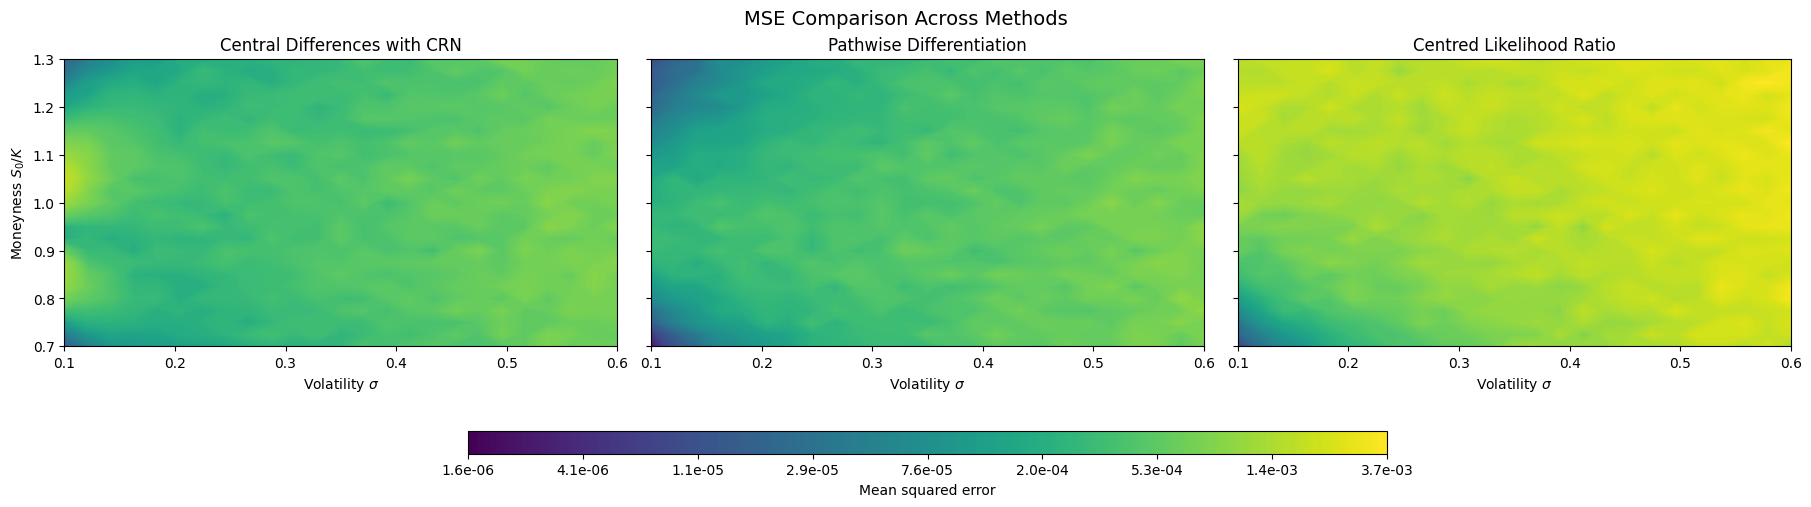

In [104]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

# Collect all values to impose a common colour scale
all_mse = np.concatenate([cd_crn_mse.ravel(), pw_mse.ravel(), lr_centred_mse.ravel()])

# Find bounds of obtained data
mse_vmin = all_mse.min()
mse_vmax = all_mse.max()

# Add many levels for smoother colour transitions and better visualisation
mse_levels = np.geomspace(mse_vmin, mse_vmax, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

mse_data = [cd_crn_mse, pw_mse, lr_centred_mse]
titles = ["Central Differences with CRN", "Pathwise Differentiation", "Centred Likelihood Ratio"]

for ax, data, title in zip(axes, mse_data, titles):
    contour = ax.contourf(VOL, MONEYNESS, data, levels=mse_levels, norm=LogNorm(vmin=mse_vmin, vmax=mse_vmax), cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"Volatility $\sigma$")

axes[0].set_ylabel(r"Moneyness $S_0/K$")

# Configure colorbar
mse_ticks = np.geomspace(mse_vmin, mse_vmax, 9)
cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=mse_ticks)
cbar.set_label("Mean squared error")
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

fig.suptitle("MSE Comparison Across Methods", fontsize=14)

plt.show()

In [105]:
# Compute factors
cd_crn_runtime_mse = cd_crn_mse * cd_crn_runtime
pw_runtime_mse = pw_mse * pw_runtime
lr_centred_runtime_mse = lr_centred_mse * lr_centred_runtime

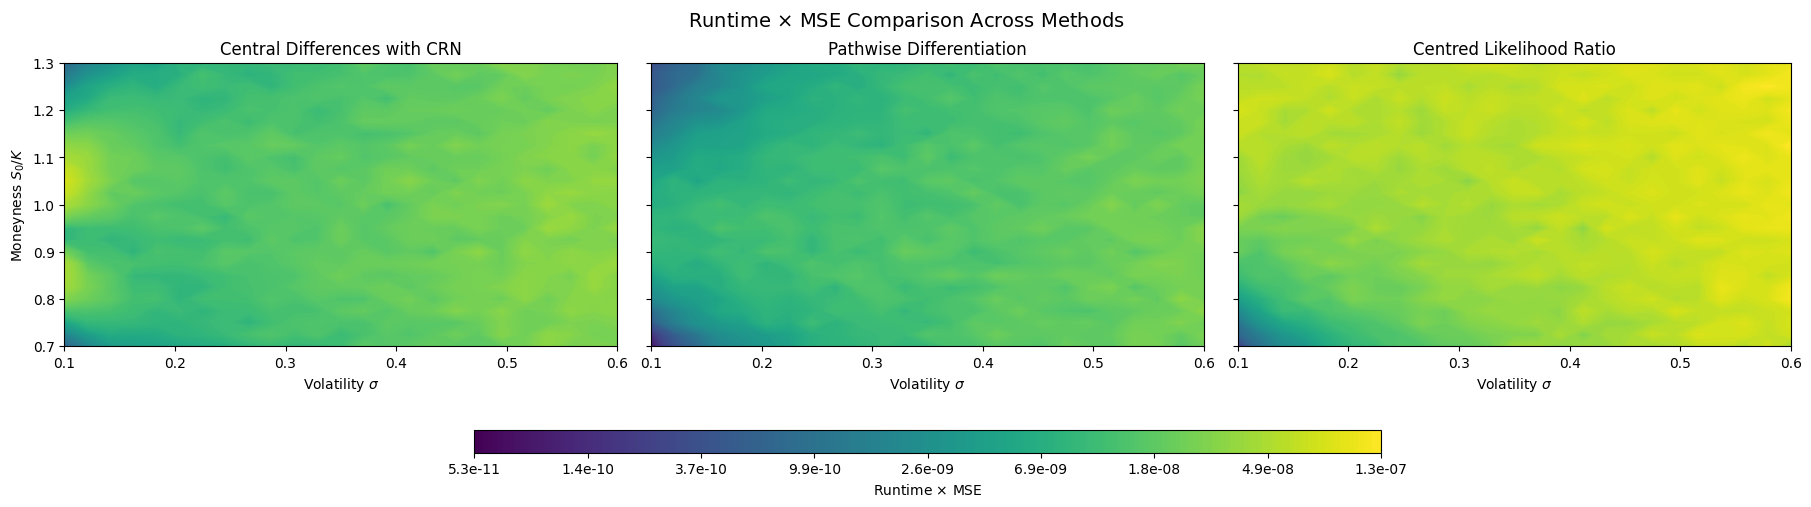

In [106]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

all_runtime_mse = np.concatenate([cd_crn_runtime_mse.ravel(), pw_runtime_mse.ravel(), lr_centred_runtime_mse.ravel()])

# Find bounds of data obtained
runtime_mse_vmin = all_runtime_mse.min()
runtime_mse_vmax = all_runtime_mse.max()

runtime_mse_levels = np.geomspace(runtime_mse_vmin, runtime_mse_vmax, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

runtime_mse_data = [cd_crn_runtime_mse, pw_runtime_mse, lr_centred_runtime_mse]
titles = ["Central Differences with CRN", "Pathwise Differentiation", "Centred Likelihood Ratio"]

for ax, data, title in zip(axes, runtime_mse_data, titles):
    contour = ax.contourf(VOL, MONEYNESS, data, levels=runtime_mse_levels, norm=LogNorm(vmin=runtime_mse_vmin, vmax=runtime_mse_vmax), cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"Volatility $\sigma$")

axes[0].set_ylabel(r"Moneyness $S_0/K$")

# Configure colorbar
runtime_mse_ticks = np.geomspace(runtime_mse_vmin, runtime_mse_vmax, 9)
cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=runtime_mse_ticks)
cbar.set_label(r"Runtime $\times$ MSE")
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

fig.suptitle(r"Runtime $\times$ MSE Comparison Across Methods", fontsize=14)

plt.show()

Clearly, the method of Pathwise Differentiation is superior using both metrics, across all Moneyness-Volatility regions on the grid. It shows lower MSE and runtime costs at the same time, making it the superior choice for estimating the Delta of a European call option.

Notice that the computation of the centring factor $c$ for each Moneyness-Volatility pair was excluded from the runtime calculation of the Likelihood-Ratio method. This shows that even under idealised MSE and runtime conditions, this method is inferior to the others, at least for European call options.

As a side remark, notice that the MSE plots for the Central Difference method with CRN appears to follow a very similar pattern to that of the Pathwise Differentiation method. This further confirms the convergence property previously investigated (which applies to CD too, and not only FD). Some differences appear in particular on the edges of both plots, which is to be expected as the optimal $h$ value computed on regions far from the center of the grid is different from the one used in this Central Difference method implementation.